In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
from copy import deepcopy
from collections import deque

class Edge:
    def __init__(self, edge_id, u, v):
        self.id = edge_id
        self.u = u
        self.v = v

    def other(self, vertex):
        return self.v if vertex == self.u else self.u

    def __repr__(self):
        return f"{self.id}:({self.u}-{self.v})"

class BrauerTree:
    def __init__(self, edges, cyclic_orderings, multiplicities=None):
        self.edges = edges
        self.cyclic_orderings = cyclic_orderings
        self.multiplicities = multiplicities or {v: 1 for v in self._extract_vertices()}

    def _extract_vertices(self):
        vertices = set()
        for edge in self.edges.values():
            vertices.add(edge.u)
            vertices.add(edge.v)
        return vertices

    def incident_edges(self, vertex):
        return self.cyclic_orderings.get(vertex, [])

    def neighbors(self, vertex):
        return [self.edges[e_id].other(vertex) for e_id in self.incident_edges(vertex) if e_id in self.edges]

    def mutate_at_edge(self, edge_id):
        if edge_id not in self.edges:
            return self

        edge = self.edges[edge_id]
        u, v = edge.u, edge.v

        is_internal = len(self.incident_edges(u)) > 1 and len(self.incident_edges(v)) > 1

        new_edges = deepcopy(self.edges)
        new_cyclic_orderings = deepcopy(self.cyclic_orderings)
        new_multiplicities = dict(self.multiplicities)

        if is_internal:
            order_u = self.cyclic_orderings[u]
            order_v = self.cyclic_orderings[v]
            idx_u = order_u.index(edge_id)
            idx_v = order_v.index(edge_id)

            tail_u = order_u[idx_u+1:] + order_u[:idx_u]
            tail_v = order_v[idx_v+1:] + order_v[:idx_v]

            new_cyclic_orderings[u] = [edge_id] + tail_v
            new_cyclic_orderings[v] = [edge_id] + tail_u

        else:
            leaf = u if len(self.incident_edges(u)) == 1 else v
            center = v if leaf == u else u

            if edge_id not in new_cyclic_orderings[center]:
                return self
            idx = new_cyclic_orderings[center].index(edge_id)
            next_idx = (idx + 1) % len(new_cyclic_orderings[center])
            target_edge = self.cyclic_orderings[center][next_idx]
            b = self.edges[target_edge].other(center)

            new_edge_id = edge_id + "'"
            i = 1
            while new_edge_id in new_edges:
                new_edge_id = edge_id + "'" + str(i)
                i += 1

            new_edges[new_edge_id] = Edge(new_edge_id, leaf, b)

            new_cyclic_orderings[center].remove(edge_id)
            new_cyclic_orderings[center].insert((idx + 1) % len(new_cyclic_orderings[center]), new_edge_id)
            del new_edges[edge_id]

        return BrauerTree(new_edges, new_cyclic_orderings, new_multiplicities)

    def mutate_until_star(self, center, max_steps=200):
        tree = self
        step = 0

        while True:
            bad_edges = [e_id for e_id, e in tree.edges.items()
                         if center not in (e.u, e.v)]
            if not bad_edges:
                break

            ordered = tree.sort_edges_by_distance(center)
            for edge_id in ordered:
                if edge_id in bad_edges:
                    tree = tree.mutate_at_edge(edge_id)
                    step += 1
                    break

            if step > max_steps:
                break

        return tree

    def draw(self, title="Brauer Tree"):
        G = nx.Graph()
        for edge in self.edges.values():
            G.add_edge(edge.u, edge.v, label=edge.id)
        pos = nx.circular_layout(G)
        edge_labels = {(e.u, e.v): e.id for e in self.edges.values()}
        nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=1200, font_size=10)
        nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red')
        plt.title(title)
        plt.axis('off')
        plt.show()

    def __str__(self):
        s = "Edges:\n"
        for eid, edge in self.edges.items():
            s += f"  {eid}: {edge.u}-{edge.v}\n"
        s += "Cyclic Orderings:\n"
        for v, order in self.cyclic_orderings.items():
            s += f"  {v}: {order}\n"
        s += "Multiplicities:\n"
        for v, m in self.multiplicities.items():
            s += f"  {v}: {m}\n"
        return s


In [ ]:
def sort_edges_by_distance(self, center):
    dist = {v: float('inf') for v in self._extract_vertices()}
    dist[center] = 0
    q = deque([center])
    while q:
        v = q.popleft()
        for n in self.neighbors(v):
            if dist[n] == float('inf'):
                dist[n] = dist[v] + 1
                q.append(n)

    def edge_key(eid):
        e = self.edges[eid]
        d = min(dist[e.u], dist[e.v])
        far = e.u if dist[e.u] > dist[e.v] else e.v
        return (-d, -ord(far[0]))  # מרחק יורד, ואז לפי קודקוד רחוק לפי שם יורד

    return sorted(self.edges.keys(), key=edge_key)

# עדכון למחלקה
BrauerTree.sort_edges_by_distance = sort_edges_by_distance


🌱 לפני מוטציה (עץ A–B–C–D):


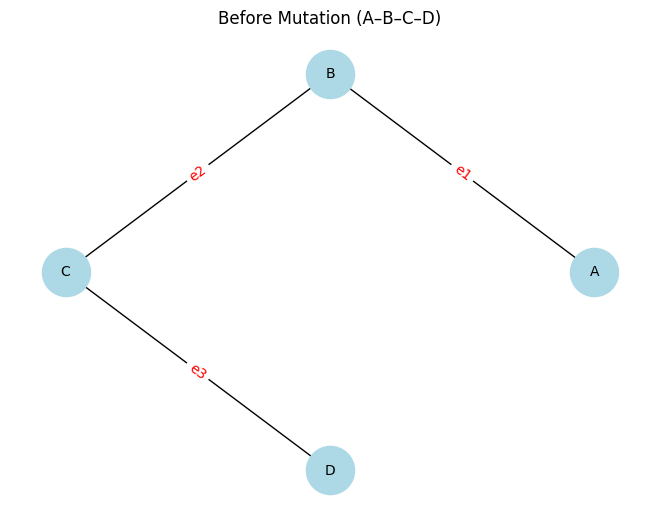

🌟 אחרי מוטציה לעץ כוכב סביב B:


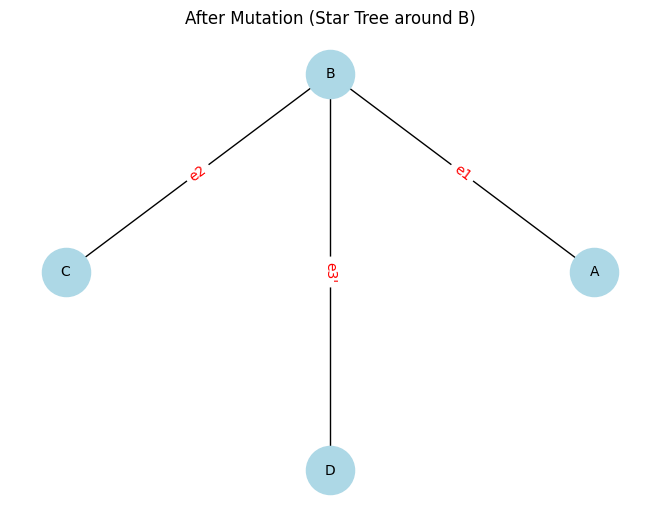

🔁 סדרים מעגליים סביב B:
['e1', 'e2']


In [ ]:
edges1 = {
    "e1": Edge("e1", "A", "B"),
    "e2": Edge("e2", "B", "C"),
    "e3": Edge("e3", "C", "D"),
}

cyclic_orderings1 = {
    "A": ["e1"],
    "B": ["e1", "e2"],
    "C": ["e2", "e3"],
    "D": ["e3"]
}

multiplicities1 = {v: 1 for v in "ABCD"}

tree1 = BrauerTree(edges1, cyclic_orderings1, multiplicities1)

print("🌱 לפני מוטציה (עץ A–B–C–D):")
tree1.draw("Before Mutation (A–B–C–D)")

star_tree1 = tree1.mutate_until_star(center="B")

print("🌟 אחרי מוטציה לעץ כוכב סביב B:")
star_tree1.draw("After Mutation (Star Tree around B)")

print("🔁 סדרים מעגליים סביב B:")
print(star_tree1.cyclic_orderings["B"])


🌲 עץ לא לינארי לפני מוטציה:


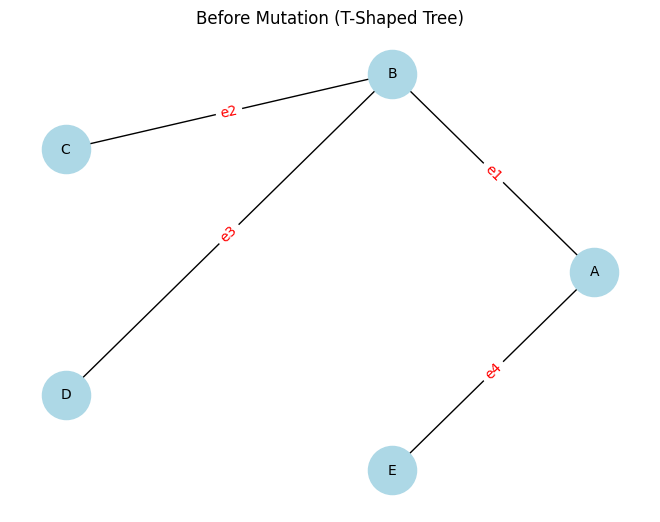

⭐ עץ לאחר הפיכת כל הקשתות לחיבור ישיר למרכז B:


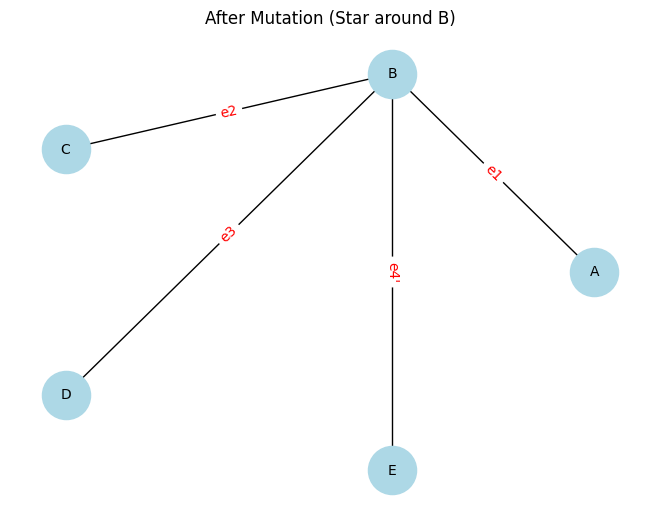

🔁 סדרים מעגליים סביב B:
['e1', 'e2', 'e3']


In [ ]:
# הגדרת עץ בצורת T:
#      A
#      |
#  E – B – C
#      |
#      D

edges3 = {
    "e1": Edge("e1", "A", "B"),
    "e2": Edge("e2", "C", "B"),
    "e3": Edge("e3", "D", "B"),
    "e4": Edge("e4", "E", "A"),
}

cyclic_orderings3 = {
    "A": ["e1", "e4"],
    "B": ["e1", "e2", "e3"],
    "C": ["e2"],
    "D": ["e3"],
    "E": ["e4"],
}

multiplicities3 = {v: 1 for v in "ABCDE"}

tree3 = BrauerTree(edges3, cyclic_orderings3, multiplicities3)

print("🌲 עץ לא לינארי לפני מוטציה:")
tree3.draw("Before Mutation (T-Shaped Tree)")

star_tree3 = tree3.mutate_until_star(center="B")

print("⭐ עץ לאחר הפיכת כל הקשתות לחיבור ישיר למרכז B:")
star_tree3.draw("After Mutation (Star around B)")

print("🔁 סדרים מעגליים סביב B:")
print(star_tree3.cyclic_orderings["B"])
